# JOBSHEET 3 - PERBAIKAN CITRA DALAM DOMAIN SPASIAL

Nama: Tsabitah Hilyatul Aulia  
NIM: 3.34.23.3.23  
Kelas: IK-3D  
Mata Kuliah: Pengolahan Citra  

## P1 - Transormasi Kurva (Citra Negatif)

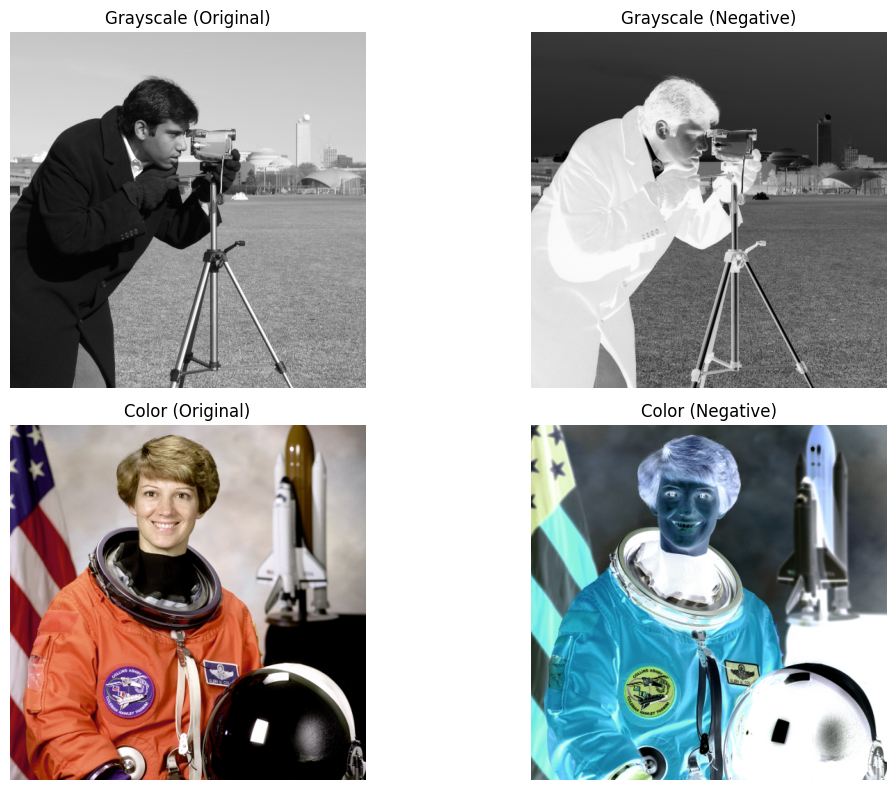

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float

# ===================
# 1. TRANSFORMASI NEGATIF CITRA GRAYSCALE
# ===================
image_gray_uint8 = data.camera() # Citra grayscale (512x512, 0..255)
image_gray_float = img_as_float(image_gray_uint8) # Konversi ke float [0..1]

negative_gray = 1.0 - image_gray_float # Inversi intensitas: output = 1 - input

# ===================
# 2. TRANSFORMASI NEGATIF CITRA BERWARNA
# ===================
image_color_uint8 = data.astronaut()	# Citra berwarna (512x512x3, 0..255)
image_color_float = img_as_float(image_color_uint8) # Konversi ke float [0..1]

negative_color = 1.0 - image_color_float # Inversi intensitas tiap kanal RGB

# ===================
# 3. PLOTTING HASIL
# ===================
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Baris 1: Grayscale (original, negative)
axes[0, 0].imshow(image_gray_float, cmap='gray')
axes[0, 0].set_title("Grayscale (Original)")
axes[0, 0].axis('off')

axes[0, 1].imshow(negative_gray, cmap='gray')
axes[0, 1].set_title("Grayscale (Negative)")
axes[0, 1].axis('off')

# Baris 2: RGB (original, negative)
axes[1, 0].imshow(image_color_float)
axes[1, 0].set_title("Color (Original)")
axes[1, 0].axis('off')

axes[1, 1].imshow(negative_color)
axes[1, 1].set_title("Color (Negative)")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

## P2 - Histogram dan Ekualisasi Histogram

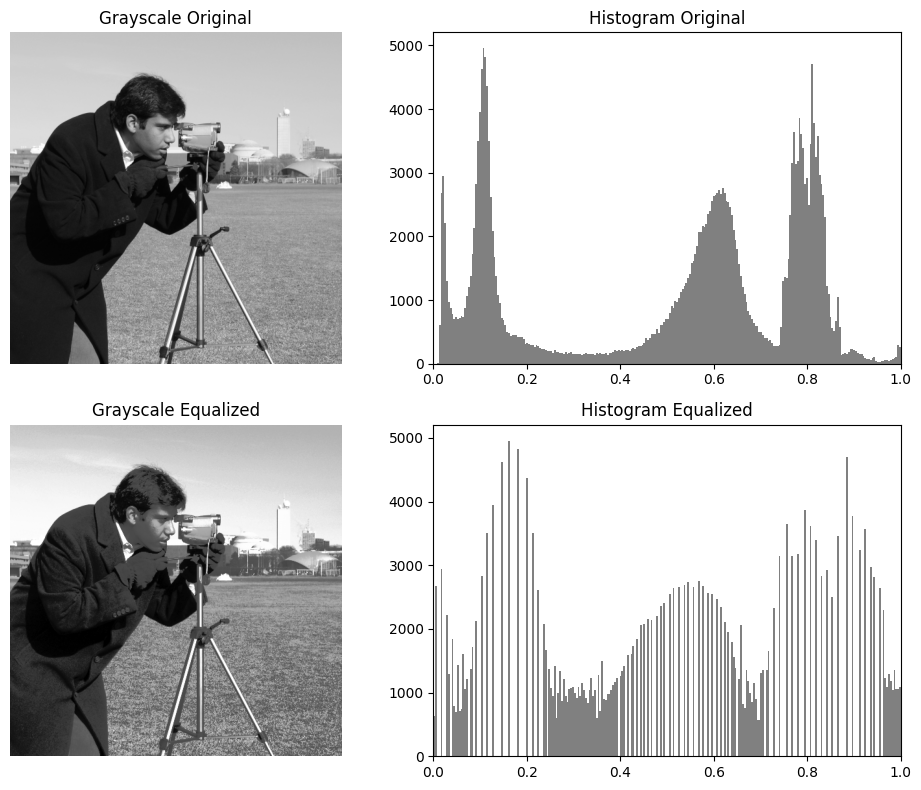

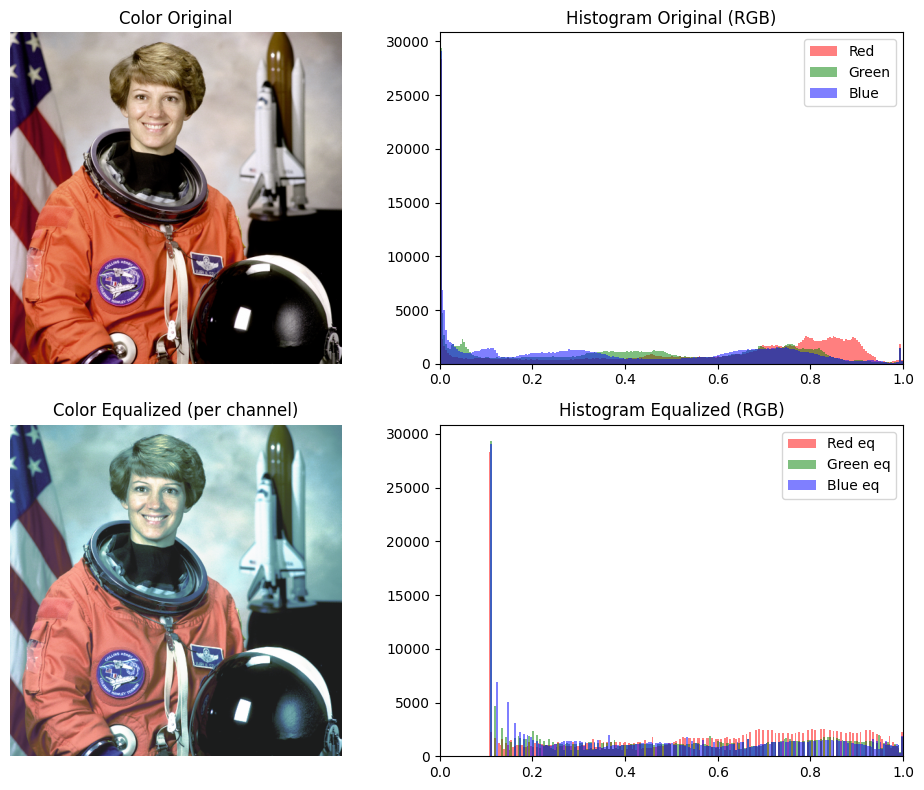

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure, img_as_float

#
# BAGIAN 1: HISTOGRAM & EKUALISASI HISTOGRAM (GRAYSCALE)
#

# 1. Memuat citra grayscale
image_gray_uint8 = data.camera() # sudah grayscale (uint8, 0..255)
image_gray = img_as_float(image_gray_uint8) # konversi ke float [0..1]

# 2. Menghitung histogram citra asli (dengan numpy.histogram)
# Kita perbesar bins=256 untuk melihat distribusi piksel
hist_gray, bins_gray = np.histogram(image_gray.ravel(), bins=256, range=(0,1))

# 3. Ekualisasi histogram
# Dengan skimage.exposure.equalize_hist, hasil di rentang [0..1]
image_gray_eq = exposure.equalize_hist(image_gray)
hist_gray_eq, bins_gray_eq = np.histogram(image_gray_eq.ravel(), bins=256, range=(0,1))

# 4. Plot grayscale: citra asli & histogram, citra ekualisasi & histogram
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# (a) Citra Asli Grayscale
axes[0, 0].imshow(image_gray, cmap='gray')
axes[0, 0].set_title("Grayscale Original")
axes[0, 0].axis('off')

# (b) Histogram Citra Asli
axes[0, 1].hist(image_gray.ravel(), bins=256, range=(0,1), color='gray')
axes[0, 1].set_title("Histogram Original")
axes[0, 1].set_xlim(0,1)

# (c) Citra Hasil Ekualisasi
axes[1, 0].imshow(image_gray_eq, cmap='gray')
axes[1, 0].set_title("Grayscale Equalized")
axes[1, 0].axis('off')

# (d) Histogram Citra Hasil Ekualisasi
axes[1, 1].hist(image_gray_eq.ravel(), bins=256, range=(0,1), color='gray')
axes[1, 1].set_title("Histogram Equalized")
axes[1, 1].set_xlim(0,1)

plt.tight_layout()
plt.show()

#
# BAGIAN 2: HISTOGRAM & EKUALISASI HISTOGRAM (CITRA WARNA)
#

# 1. Memuat citra berwarna
image_color_uint8 = data.astronaut() # citra berwarna RGB (uint8)
image_color = img_as_float(image_color_uint8) # konversi ke float [0..1]

# 2. Kita dapat menghitung histogram gabungan (semua kanal) atau per kanal
# Di sini kita tampilkan histogram gabungan R, G, B untuk citra asli.
r_channel = image_color[:,:,0]
g_channel = image_color[:,:,1]
b_channel = image_color[:,:,2]

# Hitung histogram untuk tiap kanal, 256 bins
hist_r, bins_r = np.histogram(r_channel.ravel(), bins=256, range=(0,1))
hist_g, bins_g = np.histogram(g_channel.ravel(), bins=256, range=(0,1))
hist_b, bins_b = np.histogram(b_channel.ravel(), bins=256, range=(0,1))

# 3. Ekualisasi histogram tiap kanal secara independen
# (Catatan: cara ini bisa mengubah keseimbangan warna.
# Terkadang lebih baik melakukan ekualisasi hanya pada kanal luminance (Y)
# atau Value (HSV). Tapi di sini kita tunjukkan contoh per kanal.)
r_eq = exposure.equalize_hist(r_channel)
g_eq = exposure.equalize_hist(g_channel)
b_eq = exposure.equalize_hist(b_channel)

# Gabungkan kembali menjadi citra RGB yang sudah di-ekualisasi
image_color_eq = np.dstack((r_eq, g_eq, b_eq))

# Hitung histogram citra berwarna ekualisasi (tiap kanal)
hist_r_eq, bins_r_eq = np.histogram(r_eq.ravel(), bins=256, range=(0,1))
hist_g_eq, bins_g_eq = np.histogram(g_eq.ravel(), bins=256, range=(0,1))
hist_b_eq, bins_b_eq = np.histogram(b_eq.ravel(), bins=256, range=(0,1))

# 4. Plot citra berwarna & histogram
fig2, axes2 = plt.subplots(2, 2, figsize=(10, 8))

# (a) Citra Asli (Color)
axes2[0, 0].imshow(image_color)
axes2[0, 0].set_title("Color Original")
axes2[0, 0].axis('off')

# (b) Histogram Asli (tumpuk R, G, B)
axes2[0, 1].hist(r_channel.ravel(), bins=256, range=(0,1), color='red', alpha=0.5, label='Red')
axes2[0, 1].hist(g_channel.ravel(), bins=256, range=(0,1), color='green', alpha=0.5, label='Green')
axes2[0, 1].hist(b_channel.ravel(), bins=256, range=(0,1), color='blue', alpha=0.5, label='Blue')
axes2[0, 1].set_title("Histogram Original (RGB)")
axes2[0, 1].set_xlim(0,1)
axes2[0, 1].legend(loc='upper right')

# (c) Citra Hasil Ekualisasi (RGB)
axes2[1, 0].imshow(image_color_eq)
axes2[1, 0].set_title("Color Equalized (per channel)")
axes2[1, 0].axis('off')

# (d) Histogram Ekualisasi (tumpuk R, G, B)
axes2[1, 1].hist(r_eq.ravel(), bins=256, range=(0,1), color='red', alpha=0.5, label='Red eq')
axes2[1, 1].hist(g_eq.ravel(), bins=256, range=(0,1), color='green', alpha=0.5, label='Green eq')
axes2[1, 1].hist(b_eq.ravel(), bins=256, range=(0,1), color='blue', alpha=0.5, label='Blue eq')
axes2[1, 1].set_title("Histogram Equalized (RGB)")
axes2[1, 1].set_xlim(0,1)
axes2[1, 1].legend(loc='upper right')

plt.tight_layout()
plt.show()

## P3 - Konvolusi (Filter Rata-rata)

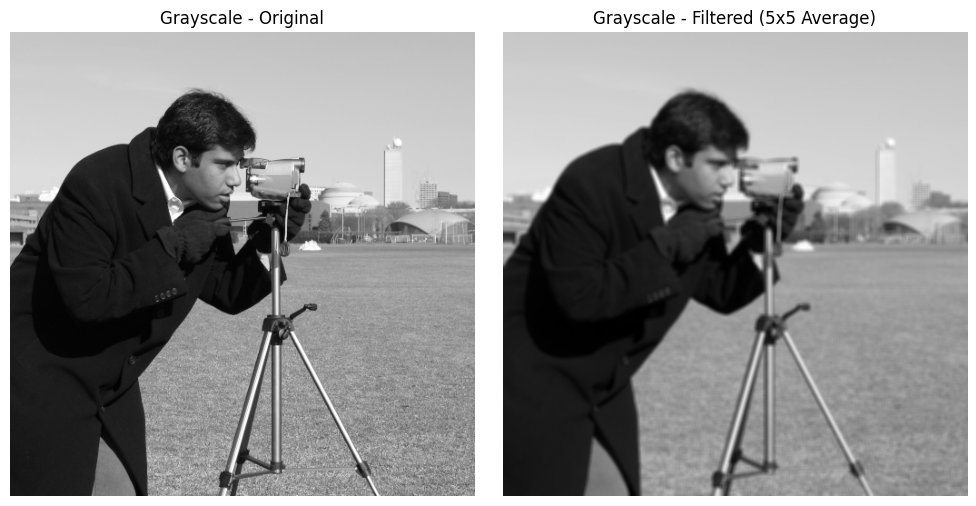

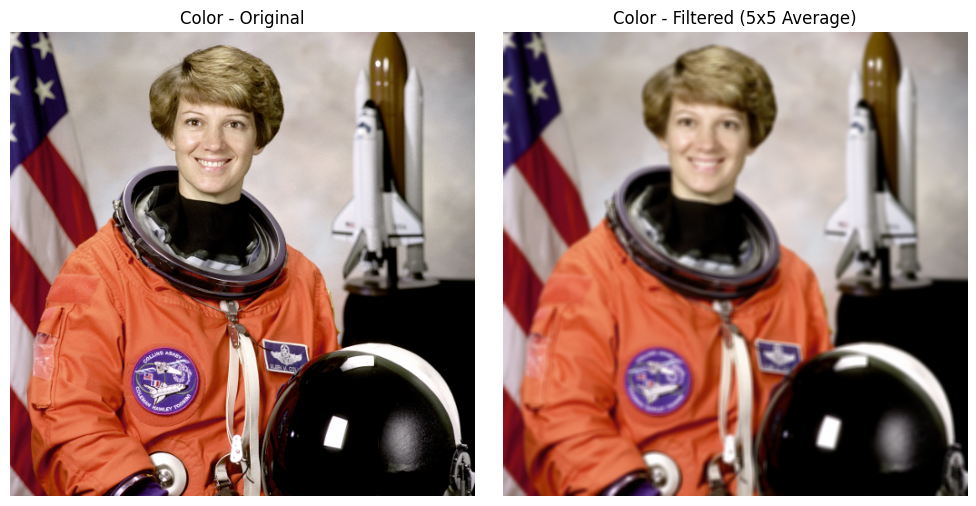

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from scipy import ndimage as ndi

# --------------------------------------------------
# 1) FILTER RATA-RATA PADA CITRA GRAYSCALE
# --------------------------------------------------

# A. Memuat citra grayscale (camera)
gray_uint8 = data.camera() # range 0..255
gray_img = img_as_float(gray_uint8) # konversi menjadi float [0..1] untuk kemudahan

# B. Definisikan kernel filter rata-rata (contoh: 5x5)
kernel_size = 5
kernel = np.ones((kernel_size, kernel_size), dtype=float) / (kernel_size * kernel_size)

# C. Lakukan konvolusi pada citra grayscale
gray_filtered = ndi.convolve(gray_img, kernel, mode='reflect')

# D. Tampilkan hasil
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(gray_img, cmap='gray')
axes[0].set_title("Grayscale - Original")
axes[0].axis('off')

axes[1].imshow(gray_filtered, cmap='gray')
axes[1].set_title(f"Grayscale - Filtered ({kernel_size}x{kernel_size} Average)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

# --------------------------------------------------
# 2) FILTER RATA-RATA PADA CITRA BERWARNA
# --------------------------------------------------

# A. Memuat citra berwarna (astronaut)
color_uint8 = data.astronaut() # citra RGB (uint8, 0..255)
color_img = img_as_float(color_uint8) # konversi float [0..1]

# B. Kita akan terapkan filter rata-rata pada tiap kanal R, G, B
# secara terpisah, lalu gabungkan.
color_filtered = np.zeros_like(color_img)

for c in range(3): # c = 0 (Red), 1 (Green), 2 (Blue)
    channel_original = color_img[:, :, c]
    channel_filtered = ndi.convolve(channel_original, kernel, mode='reflect')
    color_filtered[:, :, c] = channel_filtered

# C. Tampilkan hasil
fig2, axes2 = plt.subplots(1, 2, figsize=(10, 5))
axes2[0].imshow(color_img)
axes2[0].set_title("Color - Original")
axes2[0].axis('off')

axes2[1].imshow(color_filtered)
axes2[1].set_title(f"Color - Filtered ({kernel_size}x{kernel_size} Average)")
axes2[1].axis('off')

plt.tight_layout()
plt.show()

## P4 -  Filter Median (penghilangan noise/derau)

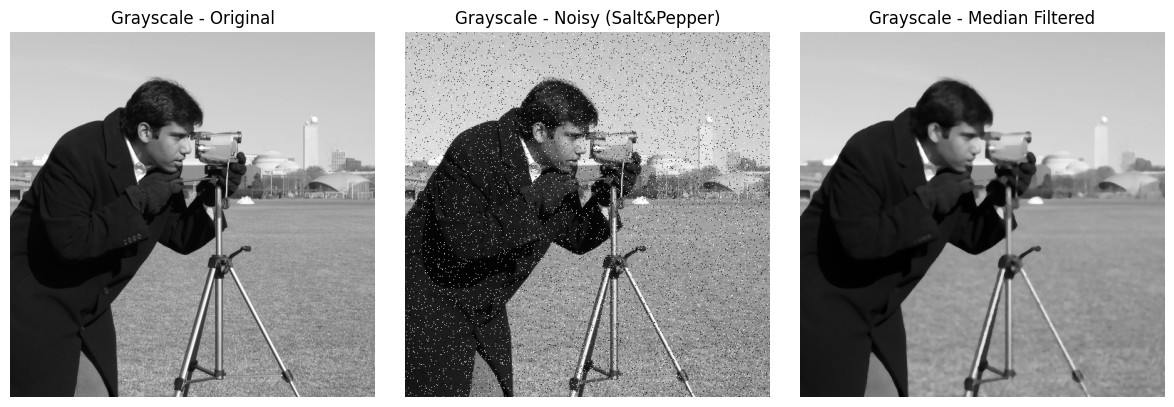

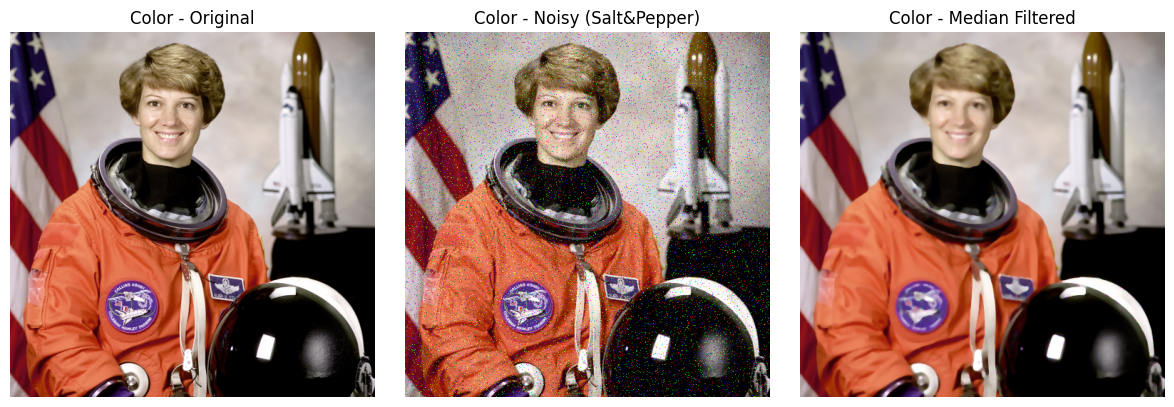

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, util, filters, morphology, img_as_float

# -----------------------------------------
# 1) FILTER MEDIAN PADA CITRA GRAYSCALE
# -----------------------------------------

# A. Memuat citra grayscale (contoh: 'camera')
gray_uint8 = data.camera() # grayscale, uint8
gray_float = img_as_float(gray_uint8) # konversi float [0..1]

# B. Menambahkan noise jenis salt-and-pepper
gray_noisy = util.random_noise(gray_float, mode='s&p', amount=0.05)
# amount=0.05 berarti 5% piksel terpengaruh noise

# C. Menerapkan filter median
# Kita gunakan structuring element berbentuk disk radius 3
disk3 = morphology.disk(3)
gray_denoised = filters.median(gray_noisy, disk3)

# D. Plot hasil
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(gray_float, cmap='gray')
axes[0].set_title("Grayscale - Original")
axes[0].axis('off')

axes[1].imshow(gray_noisy, cmap='gray')
axes[1].set_title("Grayscale - Noisy (Salt&Pepper)")
axes[1].axis('off')

axes[2].imshow(gray_denoised, cmap='gray')
axes[2].set_title("Grayscale - Median Filtered")
axes[2].axis('off')

plt.tight_layout()
plt.show()

# -----------------------------------------
# 2) FILTER MEDIAN PADA CITRA BERWARNA
# -----------------------------------------

# A. Memuat citra berwarna (contoh: 'astronaut')
color_uint8 = data.astronaut() # RGB, uint8
color_float = img_as_float(color_uint8) # rentang [0..1]

# B. Menambahkan noise salt-and-pepper
color_noisy = util.random_noise(color_float, mode='s&p', amount=0.05)

# C. Menerapkan filter median
# Pada scikit-image 0.19+, median() mampu menangani array 3D (RGB),
# atau kita bisa memanggil per kanal. Di sini langsung:
color_denoised = np.zeros_like(color_noisy)
for c in range(color_noisy.shape[2]):
    color_denoised[:, :, c] = filters.median(color_noisy[:, :, c], morphology.disk(3))

# D. Plot hasil
fig2, axes2 = plt.subplots(1, 3, figsize=(12, 4))
axes2[0].imshow(color_float)
axes2[0].set_title("Color - Original")
axes2[0].axis('off')

axes2[1].imshow(color_noisy)
axes2[1].set_title("Color - Noisy (Salt&Pepper)")
axes2[1].axis('off')

axes2[2].imshow(color_denoised)
axes2[2].set_title("Color - Median Filtered")
axes2[2].axis('off')

plt.tight_layout()
plt.show()

# PENUGASAN

## 3.	Eksperimen Transformasi Intensitas Lain

#### Cobalah menerapkan transformasi kurva lain selain citra negatif, misalnya transformasi logaritmik atau transformasi gamma. Gunakan citra grayscale yang berbeda (contoh: skimage.data.camera() vs skimage.data.astronaut() yang diubah ke grayscale). Amati perbedaan yang dihasilkan terhadap citra asli. Jelaskan bagaimana parameter (konstanta c atau gamma) memengaruhi hasil citra.
https://scikit-image.org/docs/stable/api/skimage.exposure.html#skimage.exposure.adjust_gamma


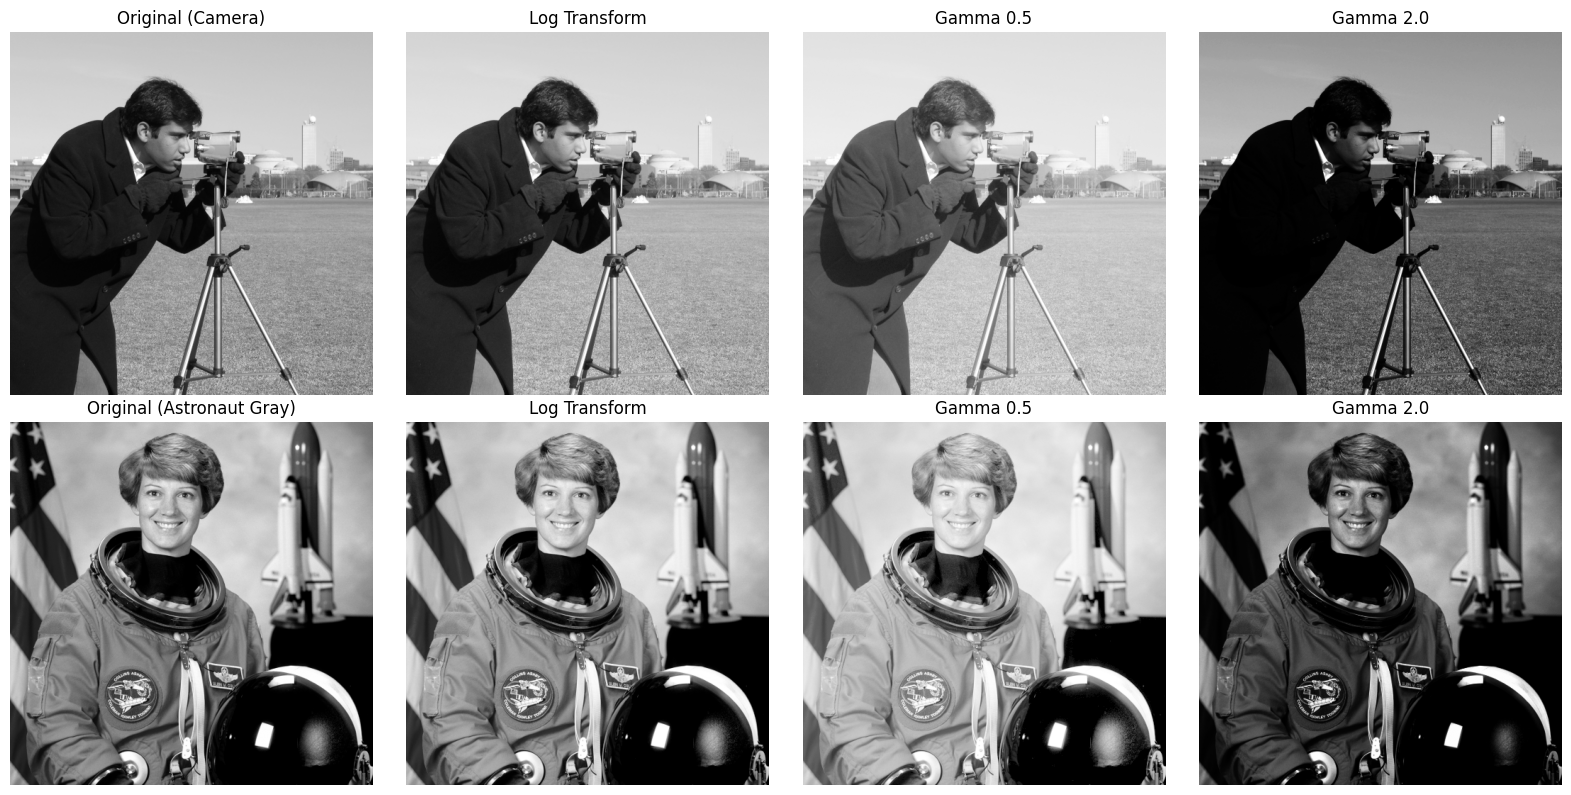

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, img_as_float
from skimage.exposure import adjust_gamma

# 1. Load citra grayscale
image1 = img_as_float(data.camera())
image2_color = data.astronaut()
image2 = img_as_float(color.rgb2gray(image2_color))

# 2. Transformasi Logaritmik
c = 1.0
log_image1 = c * np.log(1 + image1)
log_image2 = c * np.log(1 + image2)

# Normalisasi hasil log agar tetap di [0,1]
log_image1 = log_image1 / np.max(log_image1)
log_image2 = log_image2 / np.max(log_image2)

# 3. Transformasi Gamma
gamma1 = 0.5   # lebih terang
gamma2 = 2.0   # lebih gelap

gamma_image1_low = adjust_gamma(image1, gamma=gamma1)
gamma_image1_high = adjust_gamma(image1, gamma=gamma2)

gamma_image2_low = adjust_gamma(image2, gamma=gamma1)
gamma_image2_high = adjust_gamma(image2, gamma=gamma2)

# 4. Plot hasil
fig, axes = plt.subplots(2, 4, figsize=(16,8))

# Baris 1: camera
axes[0,0].imshow(image1, cmap='gray')
axes[0,0].set_title("Original (Camera)")
axes[0,1].imshow(log_image1, cmap='gray')
axes[0,1].set_title("Log Transform")
axes[0,2].imshow(gamma_image1_low, cmap='gray')
axes[0,2].set_title("Gamma 0.5")
axes[0,3].imshow(gamma_image1_high, cmap='gray')
axes[0,3].set_title("Gamma 2.0")

# Baris 2: astronaut grayscale
axes[1,0].imshow(image2, cmap='gray')
axes[1,0].set_title("Original (Astronaut Gray)")
axes[1,1].imshow(log_image2, cmap='gray')
axes[1,1].set_title("Log Transform")
axes[1,2].imshow(gamma_image2_low, cmap='gray')
axes[1,2].set_title("Gamma 0.5")
axes[1,3].imshow(gamma_image2_high, cmap='gray')
axes[1,3].set_title("Gamma 2.0")

for ax in axes.ravel():
    ax.axis('off')

plt.tight_layout()
plt.show()

## 4.	Perbandingan Metode Peningkatan Kontras

#### Bandingkan dua metode peningkatan kontras pada citra yang sama – misalnya peregangan kontras (contrast stretching) vs ekualisasi histogram. Gunakan citra grayscale dengan kontras rendah (citra yang tampak terlalu gelap atau terlalu terang). Terapkan kedua teknik tersebut (Anda bisa menggunakan fungsi exposure.rescale_intensity untuk contrast stretching, dan exposure.equalize_hist untuk histogram equalization). Tampilkan dan bandingkan hasilnya serta histogramnya. Berikan analisis: metode mana yang lebih efektif meningkatkan kontras pada citra tersebut, dan apa perbedaan karakteristik hasil kedua citra.
https://scikit-image.org/docs/stable/api/skimage.exposure.html#skimage.exposure.rescale_intensity


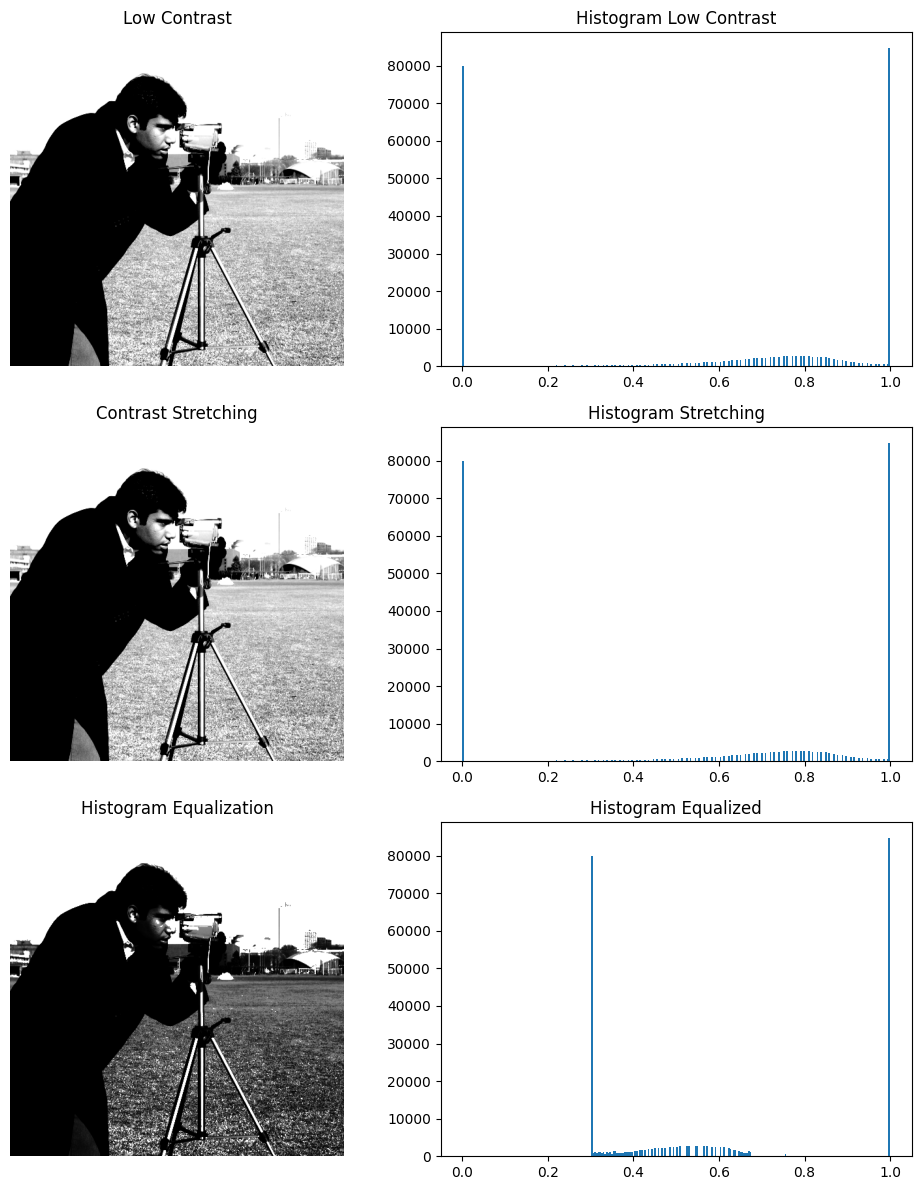

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float, exposure

# 1. Load citra grayscale
image = img_as_float(data.camera())

# 2. Membuat citra kontras rendah (simulasi)
low_contrast = exposure.rescale_intensity(image, in_range=(0.3, 0.7), out_range=(0,1))

# 3. Contrast Stretching
stretch = exposure.rescale_intensity(low_contrast, in_range='image', out_range=(0,1))

# 4. Histogram Equalization
equalized = exposure.equalize_hist(low_contrast)

# 5. Plot citra
fig, axes = plt.subplots(3, 2, figsize=(10,12))

# Citra
axes[0,0].imshow(low_contrast, cmap='gray')
axes[0,0].set_title("Low Contrast")
axes[1,0].imshow(stretch, cmap='gray')
axes[1,0].set_title("Contrast Stretching")
axes[2,0].imshow(equalized, cmap='gray')
axes[2,0].set_title("Histogram Equalization")

# Histogram
axes[0,1].hist(low_contrast.ravel(), bins=256, range=(0,1))
axes[0,1].set_title("Histogram Low Contrast")

axes[1,1].hist(stretch.ravel(), bins=256, range=(0,1))
axes[1,1].set_title("Histogram Stretching")

axes[2,1].hist(equalized.ravel(), bins=256, range=(0,1))
axes[2,1].set_title("Histogram Equalized")

for ax in axes.ravel():
    ax.axis('off') if ax in axes[:,0] else None

plt.tight_layout()
plt.show()

## 5.	Filter Median vs Filter Rata-rata

#### Uji kinerja filter median dibandingkan filter rata-rata dalam mengatasi derau. Tambahkan noise salt-and-pepper pada sebuah citra grayscale (gunakan fungsi util.random_noise). Kemudian, saring citra berderau tersebut dengan filter rata-rata (dapat menggunakan konvolusi kernel ones atau filters.gaussian untuk smoothing Gaussian) dan dengan filter median. Tampilkan hasil kedua filter dan bandingkan. Fokus pada perbedaan di tepi objek dan sisa noise yang mungkin ada. Jelaskan mengapa salah satu filter lebih unggul dari yang lain untuk kasus noise impuls.
https://scikit-image.org/docs/stable/api/skimage.util.html#skimage.util.random_noise


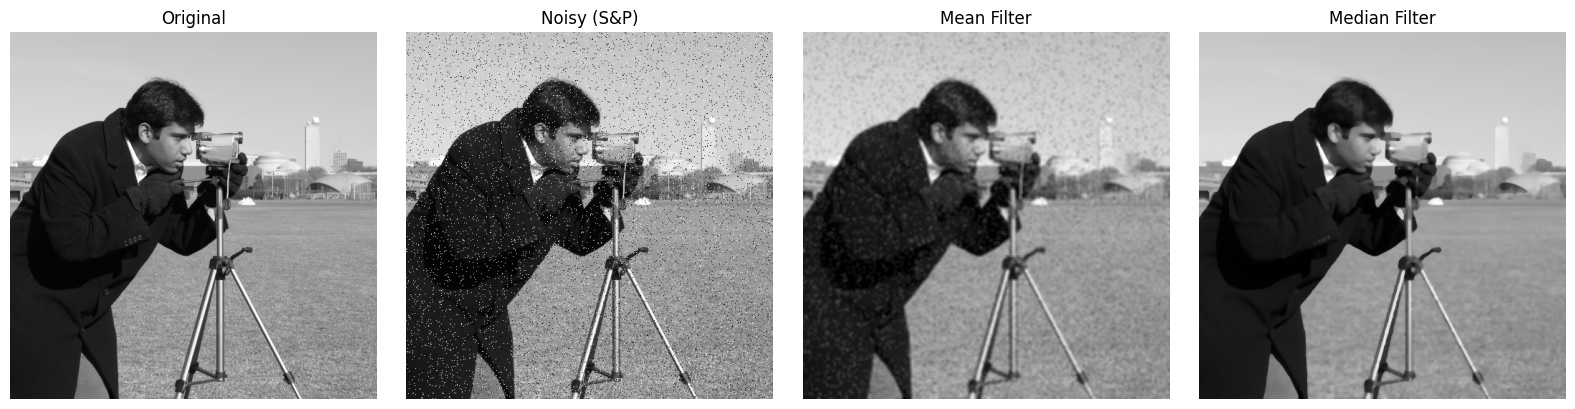

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float, util, filters, morphology
from scipy import ndimage as ndi

# 1. Load citra grayscale
image = img_as_float(data.camera())

# 2. Tambahkan noise salt-and-pepper
noisy = util.random_noise(image, mode='s&p', amount=0.05)

# 3. Filter rata-rata (mean filter)
kernel = np.ones((5,5)) / 25
mean_filtered = ndi.convolve(noisy, kernel)

# 4. Filter median
median_filtered = filters.median(noisy, morphology.disk(3))

# 5. Plot hasil
fig, axes = plt.subplots(1, 4, figsize=(16,4))

axes[0].imshow(image, cmap='gray')
axes[0].set_title("Original")

axes[1].imshow(noisy, cmap='gray')
axes[1].set_title("Noisy (S&P)")

axes[2].imshow(mean_filtered, cmap='gray')
axes[2].set_title("Mean Filter")

axes[3].imshow(median_filtered, cmap='gray')
axes[3].set_title("Median Filter")

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()